# Structured Pipeline Review

Visualises the output of the **column-aware** `annotate_page_structured()` pipeline:

1. **Pipeline progress** – live log tail + checkpoint status
2. **Column detection** – projection profile overlay with detected boundaries
3. **Strip breakdown** – each strip crop annotated individually
4. **Full-page visualisation** – merged bounding boxes on the full page
5. **Class statistics** – region counts, class distribution, per-strip breakdown

> Run `uv run python run_pipeline.py start --input data/processed` from the repo root to start the background pipeline, then use this notebook to inspect results as they arrive.

In [2]:
from __future__ import annotations
import json, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display, clear_output

# ── repo root ──────────────────────────────────────────────────────────────
REPO = Path().resolve().parent
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

# ── output dirs ───────────────────────────────────────────────────────────
LABELS_DIR = REPO / "data" / "annotations" / "labels"  / "train"
IMAGES_DIR = REPO / "data" / "annotations" / "images"  / "train"
VIS_DIR    = REPO / "data" / "annotations" / "visualizations"
PROCESSED  = REPO / "data" / "processed"
LOG_FILE   = REPO / "data" / "interim" / "pipeline.log"
PID_FILE   = REPO / "data" / "interim" / ".pipeline.pid"

# ── class colour map ──────────────────────────────────────────────────────
CLASS_COLOURS = {
    "job_advertisement":        "#FF4136",
    "article_text":             "#2ECC40",
    "headline":                 "#0074D9",
    "commercial_advertisement": "#FF851B",
    "financial_table":          "#B10DC9",
    "masthead":                 "#FFDC00",
}

print("Imports OK — repo root:", REPO)

Imports OK — repo root: C:\dev\newspapers


## 1 · Pipeline progress

In [3]:
def pipeline_status() -> dict:
    """Return a dict with pid, running state, checkpoint progress, last log lines."""
    status = {"pid": None, "running": False, "pages": {}, "last_log": []}
    if PID_FILE.exists():
        pid = int(PID_FILE.read_text())
        status["pid"] = pid
        import ctypes
        handle = ctypes.windll.kernel32.OpenProcess(0x400, False, pid)
        status["running"] = bool(handle)
        if handle:
            ctypes.windll.kernel32.CloseHandle(handle)
    for cp in sorted(VIS_DIR.glob("*_checkpoint.json")):
        try:
            data   = json.loads(cp.read_text())
            stem   = cp.stem.replace("_checkpoint", "")
            done   = data.get("completed_strips", [])
            status["pages"][stem] = {"done": done, "n_done": len(done)}
        except Exception:
            pass
    if LOG_FILE.exists():
        lines = LOG_FILE.read_text(encoding="utf-8", errors="replace").splitlines()
        status["last_log"] = lines[-20:]
    return status

st = pipeline_status()
state = "🟢 RUNNING" if st["running"] else "⚫ NOT RUNNING"
print(f"Pipeline: {state}  (PID {st['pid']})\n")
for stem, info in st["pages"].items():
    print(f"  {stem}: {info['n_done']} strips done — {info['done']}")
if not st["pages"]:
    print("  No checkpoints yet — pipeline may still be on the first strip.")
print("\n--- Last log lines ---")
print("\n".join(st["last_log"]))

Pipeline: ⚫ NOT RUNNING  (PID 63188)

  bib13991099_19000124_0_10721a_0003: 2 strips done — ['col_1', 'masthead']

--- Last log lines ---
          ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\concurrent\futures\_base.py", line 449, in result
    return self.__get_result()
           ^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\Python312\Lib\concurrent\futures\_base.py", line 401, in __get_result
    raise self._exception
  File "C:\dev\newspapers\.venv\Lib\site-packages\tenacity\__init__.py", line 473, in __call__
    result = fn(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^
  File "C:\dev\newspapers\.venv\Lib\site-packages\google\genai\_api_client.py", line 1214, in _request_once
    errors.APIError.raise_for_response(response)
  File "C:\dev\newspapers\.venv\Lib\site-packages\google\genai\errors.py", line 134, in raise_for_response
    cls.raise_error(response.status_code, response_json, response)
  File "C:\dev\newspapers\.venv\Lib\site-packages\google\gena

## 2 · Column detection — projection profile

Analysing: bib13991099_19000124_0_10721a_0002.jpg
Skew: 0.00°  |  7 column boundaries  |  10 strips


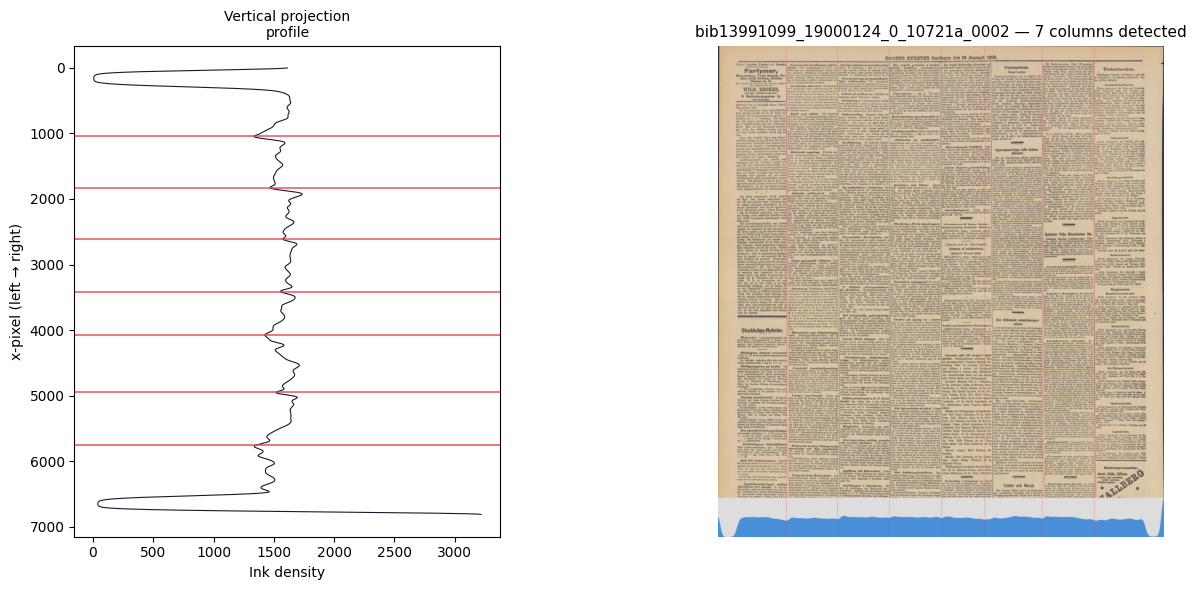

In [4]:
from newspapers.segmentation.structure import analyse_page_structure, draw_column_bounds

# ── pick the first available processed image ──────────────────────────────
jpgs = sorted(PROCESSED.glob("*.jpg"))
if not jpgs:
    raise FileNotFoundError(f"No .jpg files in {PROCESSED}")
IMAGE_PATH = jpgs[0]          # change index to view a different page
print("Analysing:", IMAGE_PATH.name)

# prefer the hi-res PNG for structure analysis if it exists
struct_img = IMAGE_PATH.with_suffix(".png") if IMAGE_PATH.with_suffix(".png").exists() else IMAGE_PATH
column_bounds, strips, profile, skew_angle = analyse_page_structure(
    struct_img, n_columns_hint=8
)
print(f"Skew: {skew_angle:.2f}°  |  {len(column_bounds)} column boundaries  |  {len(strips)} strips")

# ── plot projection profile ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 3]})

# left: profile waveform
axes[0].plot(profile, np.arange(len(profile)), color="#1a1a2e", linewidth=0.8)
axes[0].set_xlabel("Ink density"); axes[0].set_ylabel("x-pixel (left → right)")
axes[0].set_title("Vertical projection\nprofile", fontsize=10)
axes[0].invert_yaxis()
# mark detected boundaries
for x in column_bounds:
    axes[0].axhline(x, color="#E63946", linewidth=1.2, alpha=0.8)

# right: page thumbnail with column lines
vis = draw_column_bounds(Image.open(struct_img).convert("RGB"), column_bounds, profile)
thumb_w = 900
ratio   = thumb_w / vis.width
vis     = vis.resize((thumb_w, int(vis.height * ratio)), Image.LANCZOS)
axes[1].imshow(vis); axes[1].axis("off")
axes[1].set_title(f"{IMAGE_PATH.stem} — {len(column_bounds)} columns detected", fontsize=11)

plt.tight_layout()
plt.show()

## 3 · Strip crops

Each column strip (plus masthead and full-page thumbnail) shown in order.

In [ ]:
n_strips = len(strips)
cols_per_row = min(5, n_strips)
rows = (n_strips + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 3, rows * 8))
axes = np.array(axes).flatten()

for i, strip in enumerate(strips):
    img = Image.open(strip.image_path)
    axes[i].imshow(img)
    axes[i].set_title(
        f"{strip.strip_id}\n{img.width}×{img.height}",
        fontsize=8, pad=3
    )
    axes[i].axis("off")

# hide unused subplots
for j in range(n_strips, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Strips — {IMAGE_PATH.stem}", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 4 · Full-page annotation visualisation

Shows the merged, deduplicated bounding boxes on the full page.  
Re-run after the pipeline finishes to see the final result.

In [ ]:
def show_full_page_vis(stem: str) -> None:
    vis_path = VIS_DIR / f"{stem}_structured_vis.png"
    if not vis_path.exists():
        print(f"Visualisation not yet written for {stem}. Pipeline still running?")
        return
    img = Image.open(vis_path)
    # Scale to a comfortable display width
    max_w = 1000
    ratio = max_w / img.width
    img   = img.resize((max_w, int(img.height * ratio)), Image.LANCZOS)
    fig, ax = plt.subplots(figsize=(14, 18))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{stem} — structured annotation", fontsize=12)
    plt.tight_layout()
    plt.show()

# Show all completed pages
stems = sorted({p.stem.replace("_structured_vis", "")
                for p in VIS_DIR.glob("*_structured_vis.png")})

if stems:
    for stem in stems:
        show_full_page_vis(stem)
else:
    print("No completed visualisations yet. Re-run this cell once the pipeline finishes a page.")

## 5 · Interactive bounding-box explorer

Draw boxes directly on the image using matplotlib patches — hover a box to see its label in the title.

In [ ]:
def load_stats(stem: str) -> dict | None:
    p = VIS_DIR / f"{stem}_structured_stats.json"
    return json.loads(p.read_text()) if p.exists() else None

def draw_boxes_on_page(stem: str, *, min_conf: float = 0.0) -> None:
    stats = load_stats(stem)
    if stats is None:
        print(f"No stats file for {stem} yet."); return
    label_path = LABELS_DIR / f"{stem}.txt"
    if not label_path.exists():
        print(f"No label file for {stem} yet."); return

    # Load YOLO labels → convert back to pixel coords
    page_img  = Image.open(PROCESSED / f"{stem}.jpg").convert("RGB")
    pw, ph    = page_img.size
    boxes: list[dict] = []
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5: continue
        cls_id, cx, cy, bw, bh = int(parts[0]), *[float(x) for x in parts[1:]]
        x1 = int((cx - bw/2) * pw); y1 = int((cy - bh/2) * ph)
        x2 = int((cx + bw/2) * pw); y2 = int((cy + bh/2) * ph)
        CLASS_NAMES = ["job_advertisement","article_text","headline",
                       "commercial_advertisement","financial_table","masthead"]
        label = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else str(cls_id)
        boxes.append({"label": label, "x1": x1, "y1": y1, "x2": x2, "y2": y2})

    scale = 1000 / max(pw, ph)
    disp_img = page_img.resize((int(pw * scale), int(ph * scale)), Image.LANCZOS)
    dw, dh   = disp_img.size

    fig, ax = plt.subplots(figsize=(12, 18))
    ax.imshow(disp_img)

    patches = []
    for box in boxes:
        col   = CLASS_COLOURS.get(box["label"], "#AAAAAA")
        x1s   = box["x1"] * scale;  y1s = box["y1"] * scale
        bws   = (box["x2"] - box["x1"]) * scale
        bhs   = (box["y2"] - box["y1"]) * scale
        rect  = mpatches.FancyBboxPatch(
            (x1s, y1s), bws, bhs,
            boxstyle="square,pad=0",
            linewidth=1.5, edgecolor=col, facecolor=col + "30"
        )
        ax.add_patch(rect)
        ax.text(x1s + 2, y1s + 2, box["label"].replace("_", " "),
                fontsize=5, color=col, va="top",
                bbox=dict(facecolor="white", alpha=0.5, pad=0.5, linewidth=0))

    # Legend
    legend_patches = [
        mpatches.Patch(color=c, label=lbl.replace("_", " "))
        for lbl, c in CLASS_COLOURS.items()
    ]
    ax.legend(handles=legend_patches, loc="upper right", fontsize=7,
              framealpha=0.85, title="Class")
    n = len(boxes)
    ax.set_title(f"{stem} — {n} detected regions", fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

# ── show all finished pages ───────────────────────────────────────────────
label_stems = sorted({p.stem for p in LABELS_DIR.glob("*.txt")})
if label_stems:
    for stem in label_stems:
        draw_boxes_on_page(stem)
else:
    print("No label files yet — re-run once the pipeline completes a page.")

## 6 · Class distribution & per-strip statistics

In [ ]:
stats_files = sorted(VIS_DIR.glob("*_structured_stats.json"))

if not stats_files:
    print("No stats files yet. Re-run once the pipeline finishes at least one page.")
else:
    for sf in stats_files:
        stats = json.loads(sf.read_text())
        stem  = stats["image"].replace(".jpg", "")

        print(f"\n{'='*60}")
        print(f"  {stats['image']}")
        print(f"  Finished : {stats['annotated_at']}")
        print(f"  Models   : {stats['generator_model']} → {stats['critic_model']} ({stats['critique_rounds']} critic rounds)")
        print(f"  Skew     : {stats['skew_angle_deg']:.2f}°   Columns : {stats['n_columns']}   Overlap: {stats['overlap_frac']:.0%}")
        print(f"  Final    : {stats['final_n_regions']} regions")
        print(f"{'='*60}\n")

        # ── overall class distribution ────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # bar chart of final classes
        cls_counts = stats["final_class_counts"]
        colours    = [CLASS_COLOURS.get(c, "#999") for c in cls_counts]
        axes[0].bar([c.replace("_", "\n") for c in cls_counts], cls_counts.values(),
                    color=colours, edgecolor="white", linewidth=0.8)
        axes[0].set_title(f"Final region distribution — {stem}", fontsize=10)
        axes[0].set_ylabel("# regions")
        for i, (k, v) in enumerate(cls_counts.items()):
            axes[0].text(i, v + 0.1, str(v), ha="center", va="bottom", fontsize=8)

        # pie chart
        axes[1].pie(cls_counts.values(),
                    labels=[c.replace("_", "\n") for c in cls_counts],
                    colors=colours, autopct="%1.0f%%", startangle=140,
                    textprops={"fontsize": 7})
        axes[1].set_title("Proportion by class", fontsize=10)

        plt.tight_layout()
        plt.show()

        # ── per-strip table ───────────────────────────────────────────
        strip_rows = []
        for s in stats["strips"]:
            row = {"strip": s["strip_id"], "col": s.get("column_index")}
            row.update(s["class_counts"])
            row["TOTAL"] = s["n_regions"]
            strip_rows.append(row)
        df = pd.DataFrame(strip_rows).set_index("strip").fillna(0).astype(
            {c: int for c in pd.DataFrame(strip_rows).columns if c not in ("strip", "col")}
        )
        print("Per-strip region counts:")
        display(df)

## 7 · Strip-level annotation detail

View the individual strip crops side-by-side with their detected boxes overlaid.

In [ ]:
def draw_strip_annotations(stem: str) -> None:
    """Draw per-strip Gemini boxes on the strip crop images."""
    cache_dir = VIS_DIR / f"{stem}_strips_cache"
    stats     = load_stats(stem)
    if stats is None:
        print(f"No stats for {stem}."); return

    # collect (strip_id, image_path, regions) triples
    strip_data = []
    for strip in strips:  # `strips` from cell 2 — re-run cell 2 first
        if strip.image_path.exists():
            cache_file = cache_dir / f"{strip.strip_id}.json"
            if cache_file.exists():
                items = json.loads(cache_file.read_text())
                strip_data.append((strip, items))

    if not strip_data:
        print("No cached strip annotations found (pipeline may still be running).")
        return

    n = len(strip_data)
    cols_per_row = min(4, n)
    rows = (n + cols_per_row - 1) // cols_per_row
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 3.5, rows * 7))
    axes = np.array(axes).flatten()

    for i, (strip, items) in enumerate(strip_data):
        img   = Image.open(strip.image_path).convert("RGB")
        sw, sh = img.size
        axes[i].imshow(img)
        for item in items:
            box = item.get("box", [])
            lbl = item.get("label", "")
            if len(box) != 4: continue
            y1, x1, y2, x2 = box
            # box is 0-1000 normalised to the strip
            px1 = x1 / 1000 * sw; py1 = y1 / 1000 * sh
            bw  = (x2 - x1) / 1000 * sw; bh = (y2 - y1) / 1000 * sh
            col = CLASS_COLOURS.get(lbl, "#AAAAAA")
            axes[i].add_patch(mpatches.FancyBboxPatch(
                (px1, py1), bw, bh,
                boxstyle="square,pad=0", linewidth=1.2,
                edgecolor=col, facecolor=col + "28"
            ))
            axes[i].text(px1 + 1, py1 + 1, lbl.replace("_", " "),
                         fontsize=4.5, color=col, va="top",
                         bbox=dict(facecolor="white", alpha=0.45, pad=0.3, linewidth=0))
        axes[i].set_title(f"{strip.strip_id} ({len(items)} regions)", fontsize=7, pad=2)
        axes[i].axis("off")

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"Per-strip annotations — {stem}", fontsize=11, y=1.005)
    plt.tight_layout()
    plt.show()

# ── draw for the image currently loaded in cell 2 ──────────────────────
draw_strip_annotations(IMAGE_PATH.stem)

## 8 · Multi-page comparison

Compare class counts across all processed pages in a single heatmap.

In [ ]:
rows = []
for sf in sorted(VIS_DIR.glob("*_structured_stats.json")):
    s = json.loads(sf.read_text())
    row = {"page": s["image"], "total": s["final_n_regions"],
           "skew_deg": s.get("skew_angle_deg", 0)}
    row.update(s["final_class_counts"])
    rows.append(row)

if not rows:
    print("No completed pages yet.")
else:
    df_all = pd.DataFrame(rows).set_index("page").fillna(0)
    CLASS_NAMES = list(CLASS_COLOURS.keys())
    heat_cols = [c for c in CLASS_NAMES if c in df_all.columns]

    import matplotlib.colors as mcolors

    fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(df_all) * 0.8 + 2)),
                              gridspec_kw={"width_ratios": [3, 1]})

    # Heatmap
    heat_data = df_all[heat_cols].values.astype(float)
    im = axes[0].imshow(heat_data, aspect="auto", cmap="YlOrRd")
    axes[0].set_xticks(range(len(heat_cols)))
    axes[0].set_xticklabels([c.replace("_", "\n") for c in heat_cols], fontsize=7)
    axes[0].set_yticks(range(len(df_all)))
    axes[0].set_yticklabels(df_all.index, fontsize=7)
    axes[0].set_title("Region counts by class (heatmap)", fontsize=10)
    plt.colorbar(im, ax=axes[0], shrink=0.6, label="count")
    # annotate cells
    for r in range(len(df_all)):
        for c in range(len(heat_cols)):
            val = int(heat_data[r, c])
            axes[0].text(c, r, str(val), ha="center", va="center", fontsize=6,
                         color="black" if val < heat_data.max() * 0.6 else "white")

    # Total bar chart
    df_all["total"].plot(kind="barh", ax=axes[1], color="#1a1a2e", edgecolor="white")
    axes[1].set_title("Total regions", fontsize=10)
    axes[1].set_xlabel("# regions")
    for i, v in enumerate(df_all["total"]):
        axes[1].text(v + 0.3, i, str(int(v)), va="center", fontsize=7)

    plt.tight_layout()
    plt.show()

    display(df_all[["total", "skew_deg"] + heat_cols].sort_values("total", ascending=False))

## 9 · Live log tail

Re-run this cell at any time to see the latest pipeline log output.

In [ ]:
N_LINES = 40  # how many tail lines to show

if LOG_FILE.exists():
    lines = LOG_FILE.read_text(encoding="utf-8", errors="replace").splitlines()
    tail  = lines[-N_LINES:]
    st    = pipeline_status()
    state = "🟢 RUNNING" if st["running"] else "⚫ FINISHED / NOT RUNNING"
    print(f"Pipeline: {state}  (PID {st['pid']})  —  {len(lines)} total log lines\n")
    print("\n".join(tail))
else:
    print(f"Log file not found: {LOG_FILE}")